# 確率的シミュレーション：反復と不確かさ

対応章：[確率的シミュレーションの基礎](../chapters/32_agent_boarding_behavior.md)．

空間を省略したボトルネック模型で，理論分布と実装を照合する．負の二項分布，打切り，対応のある比較を順に学ぶ．31章のCAと同一モデルではない．

## ライブラリと基準設定

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

N_ALIGHT, N_BOARD, PASS_PROBABILITY = 24, 20, 0.72

## 1ステップに1回の通過判定

毎ステップ独立な一様乱数 `U[t]` を1個だけ使い，`U[t] < p` なら1人が通る．最後の降車者が通った同じステップに乗車者まで通してはいけない．通過待ち人数が0なら時刻0で完了する．`p=0` も計算上限で停止する．

完了時刻は観測できた場合のみ数値を持ち，未完了は `NaN` と終了状態を記録する．`capped_time` は `min(T,C)` であり，完了時刻とは別の量である．

In [2]:
def check_counts_probability(n_alight, n_board, pass_probability, max_steps):
    if any(not isinstance(n, (int, np.integer)) or n < 0 for n in [n_alight, n_board]):
        raise ValueError('counts must be nonnegative integers')
    if not np.isfinite(pass_probability) or not 0 <= pass_probability <= 1:
        raise ValueError('pass_probability must be in [0, 1]')
    if not isinstance(max_steps, (int, np.integer)) or max_steps < 1:
        raise ValueError('max_steps must be a positive integer')


def simulate_baseline(seed=0, n_alight=24, n_board=20, pass_probability=0.72,
                      max_steps=1000, uniforms=None):
    check_counts_probability(n_alight, n_board, pass_probability, max_steps)
    if uniforms is None:
        uniforms = np.random.default_rng(seed).random(max_steps)
    else:
        uniforms = np.asarray(uniforms, dtype=float)
        if uniforms.shape != (max_steps,) or not np.isfinite(uniforms).all() or np.any((uniforms < 0) | (uniforms >= 1)):
            raise ValueError('uniforms must have max_steps values in [0, 1)')
    remaining_alight, remaining_board = n_alight, n_board
    history = [(0, remaining_alight, remaining_board)]
    time = 0
    while remaining_alight+remaining_board > 0 and time < max_steps:
        success = uniforms[time] < pass_probability
        time += 1
        if success:
            if remaining_alight:
                remaining_alight -= 1
            else:
                remaining_board -= 1
        history.append((time, remaining_alight, remaining_board))
    completed = remaining_alight+remaining_board == 0
    return dict(completion_time=float(time) if completed else np.nan, completed=completed,
                status='completed' if completed else 'cutoff', cutoff=not completed,
                capped_time=float(time), horizon=max_steps, remaining=remaining_alight+remaining_board,
                history=np.asarray(history))


def analytic_moments(total, p):
    check_counts_probability(total, 0, p, 1)
    if total == 0:
        return 0.0, 0.0
    if p == 0:
        return np.inf, np.nan
    return total/p, total*(1-p)/p**2


def mean_summary(values):
    sample = np.asarray(values, dtype=float)
    if sample.ndim != 1 or sample.size < 2 or not np.isfinite(sample).all():
        raise ValueError('need at least two finite observations; do not silently drop censored values')
    n = sample.size
    sd = sample.std(ddof=1)
    se = sd/np.sqrt(n)
    margin = stats.t.ppf(0.975, n-1)*se
    return dict(n=n, mean=sample.mean(), median=np.median(sample), std=sd, se=se,
                q25=np.quantile(sample, 0.25), q75=np.quantile(sample, 0.75),
                ci_low=sample.mean()-margin, ci_high=sample.mean()+margin)


def wilson_interval(successes, n, confidence=0.95):
    if not isinstance(n, (int, np.integer)) or not isinstance(successes, (int, np.integer)) or n < 1 or not 0 <= successes <= n:
        raise ValueError('invalid binomial counts')
    if not 0 < confidence < 1:
        raise ValueError('confidence must be in (0, 1)')
    z = stats.norm.ppf((1+confidence)/2)
    phat = successes/n
    denominator = 1+z*z/n
    center = (phat+z*z/(2*n))/denominator
    half = z*np.sqrt(phat*(1-phat)/n+z*z/(4*n*n))/denominator
    low = 0.0 if successes == 0 else max(0.0, center-half)
    high = 1.0 if successes == n else min(1.0, center+half)
    return low, high


def repeat_trials(n=200, master_seed=2026, **kwargs):
    if not isinstance(n, (int, np.integer)) or n < 1:
        raise ValueError('n must be a positive integer')
    streams = np.random.SeedSequence(master_seed).spawn(n)
    rows = []
    for replicate, seed in enumerate(streams):
        result = simulate_baseline(seed=seed, **kwargs)
        rows.append(dict(replicate=replicate, master_seed=master_seed,
                         **{key: result[key] for key in ['completion_time', 'capped_time', 'completed',
                                                        'status', 'cutoff', 'horizon', 'remaining']}))
    return pd.DataFrame(rows)

In [3]:
trial = simulate_baseline(seed=0)
repeat = simulate_baseline(seed=0)
np.testing.assert_array_equal(trial['history'], repeat['history'])
assert simulate_baseline(n_alight=2, n_board=3, pass_probability=1, max_steps=5)['completion_time'] == 5
assert simulate_baseline(n_alight=1, n_board=0, pass_probability=0, max_steps=5)['status'] == 'cutoff'
print('completion time:', trial['completion_time'])
print('reproduction and endpoint checks passed')

completion time: 62.0
reproduction and endpoint checks passed


## 1回の実行経過

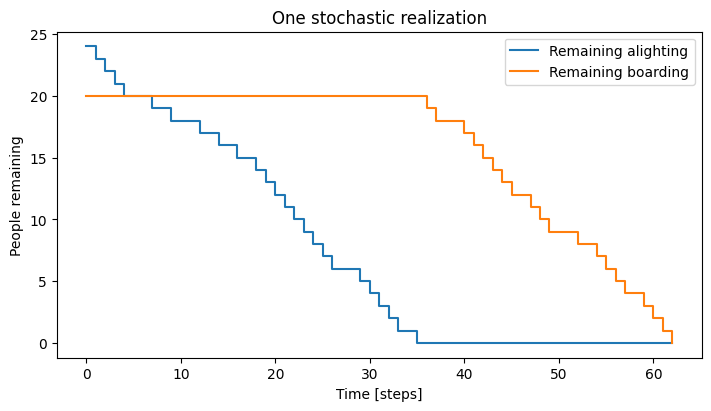

In [4]:
history = trial['history']
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)
ax.step(history[:, 0], history[:, 1], where='post', label='Remaining alighting')
ax.step(history[:, 0], history[:, 2], where='post', label='Remaining boarding')
ax.set(xlabel='Time [steps]', ylabel='People remaining', title='One stochastic realization')
ax.legend()
plt.show()

## 独立な反復と理論分布

合計 `m=44` 人の完了時刻は幾何分布の和であり，平均 `m/p`，分散 `m*(1-p)/p**2` を持つ．SciPyの `nbinom` は失敗回数を数えるため，完了時刻を得るには `m` を足す．反復には `SeedSequence.spawn` による別の乱数列を使う．

In [5]:
raw = repeat_trials(n=400)
assert raw['completed'].all(), 'censoring requires the separate analysis below'
times = raw['completion_time'].to_numpy()
mean_exact, variance_exact = analytic_moments(N_ALIGHT+N_BOARD, PASS_PROBABILITY)
display(pd.DataFrame([mean_summary(times)]))
print('exact mean:', mean_exact, 'exact variance:', variance_exact)

,n,mean,median,std,se,q25,q75,ci_low,ci_high
0,400,61.3475,61.0,4.604862,0.230243,58.0,64.0,60.894859,61.800141


exact mean: 61.111111111111114 exact variance: 23.765432098765434


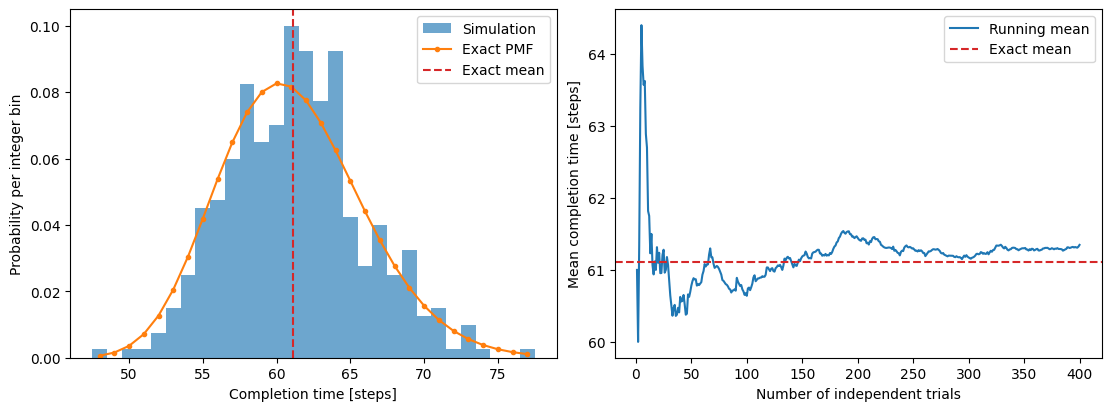

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
grid = np.arange(int(times.min()), int(times.max())+1)
axes[0].hist(times, bins=np.arange(grid.min()-0.5, grid.max()+1.5), density=True, alpha=0.65, label='Simulation')
axes[0].plot(grid, stats.nbinom.pmf(grid-44, 44, 0.72), 'o-', markersize=3, label='Exact PMF')
axes[0].axvline(mean_exact, color='tab:red', linestyle='--', label='Exact mean')
axes[0].set(xlabel='Completion time [steps]', ylabel='Probability per integer bin')
axes[0].legend()
n = np.arange(1, len(times)+1)
axes[1].plot(n, np.cumsum(times)/n, label='Running mean')
axes[1].axhline(mean_exact, color='tab:red', linestyle='--', label='Exact mean')
axes[1].set(xlabel='Number of independent trials', ylabel='Mean completion time [steps]')
axes[1].legend()
plt.show()

## 標準偏差・標準誤差・近似信頼区間

標準偏差は試行のばらつき，標準誤差は平均の推定精度である．下の各行は同じ標本の先頭部分を使うので，互いに独立な実験ではない．t分布による区間はこの非正規分布には近似であり，小標本や強い歪みでは注意する．

In [7]:
precision = pd.DataFrame([mean_summary(times[:n]) for n in [10, 30, 100, 400]])
precision['theoretical_se'] = np.sqrt(variance_exact/precision['n'])
display(precision)

,n,mean,median,std,se,q25,q75,ci_low,ci_high,theoretical_se
0,10,62.700000,61.5,3.917199,1.238727,61.00,64.0,59.897805,65.502195,1.541604
1,30,60.866667,61.0,4.576803,0.835606,57.25,64.0,59.157660,62.575673,0.890046
2,100,60.640000,61.0,4.452941,0.445294,58.00,63.0,59.756440,61.523560,0.487498
3,400,61.347500,61.0,4.604862,0.230243,58.00,64.0,60.894859,61.800141,0.243749


## 打切りを完了時間と区別する

上限 `C` までの完了率と `Y=min(T,C)` の平均は全試行から計算できる．完了者だけの平均は条件付きの量である．上限が短いほど短時間で終わった例だけを選んでしまう．この練習模型では理論値と照合できる．

,C,completion_fraction,ci_low,ci_high,exact_completion,completed_only_mean,capped_mean,exact_capped_mean
0,45,0.00,0.000000,0.009512,0.000007,NaN,45.0000,44.999999
1,55,0.10,0.074299,0.133311,0.118695,53.825000,54.8825,54.828812
2,65,0.83,0.790091,0.863631,0.819985,59.858434,60.7325,60.463408
3,90,1.00,0.990488,1.000000,0.999999,61.347500,61.3475,61.111109


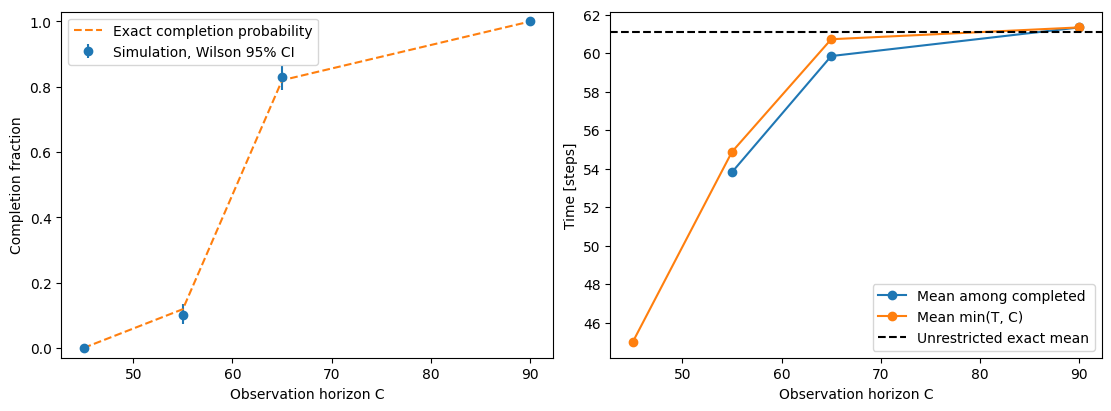

In [8]:
rows = []
for horizon in [45, 55, 65, 90]:
    sample = repeat_trials(n=400, max_steps=horizon)
    count = int(sample['completed'].sum())
    low, high = wilson_interval(count, len(sample))
    exact_capped = stats.nbinom.sf(np.arange(horizon)-44, 44, 0.72).sum()
    rows.append(dict(C=horizon, completion_fraction=count/len(sample), ci_low=low, ci_high=high,
                     exact_completion=stats.binom.sf(43, horizon, 0.72),
                     completed_only_mean=sample['completion_time'].mean(),
                     capped_mean=sample['capped_time'].mean(), exact_capped_mean=exact_capped))
censoring = pd.DataFrame(rows)
display(censoring)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].errorbar(censoring['C'], censoring['completion_fraction'],
    yerr=[censoring['completion_fraction']-censoring['ci_low'], censoring['ci_high']-censoring['completion_fraction']],
    fmt='o', label='Simulation, Wilson 95% CI')
axes[0].plot(censoring['C'], censoring['exact_completion'], '--', label='Exact completion probability')
axes[0].set(xlabel='Observation horizon C', ylabel='Completion fraction', ylim=(-0.03, 1.03))
axes[0].legend()
for column, label in [('completed_only_mean', 'Mean among completed'), ('capped_mean', 'Mean min(T, C)')]:
    axes[1].plot(censoring['C'], censoring[column], 'o-', label=label)
axes[1].axhline(mean_exact, color='black', linestyle='--', label='Unrestricted exact mean')
axes[1].set(xlabel='Observation horizon C', ylabel='Time [steps]')
axes[1].legend()
plt.show()

## 対応のある比較

各反復で時刻別の一様乱数列を1つ作り，通過確率0.65と0.8に共通して使う．乱数の意味を時刻へ対応させている点が重要であり，単に同じseedを指定することとは区別する．以下は `min(T,C)` の差を全試行で計算する．これは行動ルールの比較ではなく統計処理の練習である．

In [9]:
rows = []
for replicate, child in enumerate(np.random.SeedSequence(91).spawn(400)):
    uniforms = np.random.default_rng(child).random(120)
    base = simulate_baseline(pass_probability=0.65, max_steps=120, uniforms=uniforms)
    alt = simulate_baseline(pass_probability=0.8, max_steps=120, uniforms=uniforms)
    rows.append(dict(replicate=replicate, base=base['capped_time'], alt=alt['capped_time']))
paired = pd.DataFrame(rows)
paired['difference'] = paired['alt']-paired['base']
display(pd.DataFrame([mean_summary(paired['difference'])]))
print('sample covariance:', paired[['base', 'alt']].cov().iloc[0, 1])
assert np.all(paired['difference'] <= 0)  # この特定の結合では成功回数が常に包含関係にある．

,n,mean,median,std,se,q25,q75,ci_low,ci_high
0,400,-12.625,-12.0,4.566894,0.228345,-15.0,-9.0,-13.073909,-12.176091


sample covariance: 13.97687343358396


## 課題：実装と検証

1. `repeat_with_fixed_seed(n)` と `repeat_with_different_seeds(n)` を実装し，同じseedで毎回初期化する場合と独立な反復の場合の分散を比較する．
2. `repeat_summary(repeat_counts)` と `plot_running_mean(times)` を実装し，平均・標準偏差・標準誤差・近似95%信頼区間を理論値と比べる．上限の打切りがないことを確認してから完了時間を集計する．
3. `cutoff_summary(horizons)` を実装し，各上限で完了率，完了者だけの平均，上限制限平均を区別する．全員の真の平均 `44/0.72` と同一視しない．
4. 共通の時刻別乱数を2条件に与える `paired_comparison(n)` を実装し，対応差の平均と標準誤差を求める．別々の条件の標準誤差を単純に足さない．
5. 31章の反復結果の表を設計する．初期配置ID，更新seed，条件，観測上限，終了状態，完了時刻，残人数，上限制限時間を保存する．

In [10]:
# 課題の反復・集計・比較関数を実装する．